In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def ideal_impulse_response(fc, N):
    M = N - 1
    hd = np.zeros(N)
    for n in range(N):
        if n == M / 2:
            hd[n] = 2 * fc
        else:
            hd[n] = (np.sin(2 * np.pi * fc * (n - M / 2))) / (np.pi * (n - M / 2))
    return hd

In [14]:
def hamming_window(N):
    M = N - 1
    w = np.zeros(N)
    for n in range(N):
        w[n] = 0.54 - .46 * np.cos((2 * np.pi * n) / M)
    return w

In [15]:
fc = 1000 / 8000
N = 21
hd = ideal_impulse_response(fc, N)
hd

array([ 3.18309886e-02,  2.50087866e-02, -9.74542958e-18, -3.21541541e-02,
       -5.30516477e-02, -4.50158158e-02,  9.74542958e-18,  7.50263597e-02,
        1.59154943e-01,  2.25079079e-01,  2.50000000e-01,  2.25079079e-01,
        1.59154943e-01,  7.50263597e-02,  9.74542958e-18, -4.50158158e-02,
       -5.30516477e-02, -3.21541541e-02, -9.74542958e-18,  2.50087866e-02,
        3.18309886e-02])

In [16]:
wn = hamming_window(N)
wn

array([0.08      , 0.102514  , 0.16785218, 0.26961878, 0.39785218,
       0.54      , 0.68214782, 0.81038122, 0.91214782, 0.977486  ,
       1.        , 0.977486  , 0.91214782, 0.81038122, 0.68214782,
       0.54      , 0.39785218, 0.26961878, 0.16785218, 0.102514  ,
       0.08      ])

In [17]:
h = hd * wn
h

array([ 2.54647909e-03,  2.56375081e-03, -1.63579163e-18, -8.66936394e-03,
       -2.11067138e-02, -2.43085405e-02,  6.64782352e-18,  6.07999526e-02,
        1.45172834e-01,  2.20011648e-01,  2.50000000e-01,  2.20011648e-01,
        1.45172834e-01,  6.07999526e-02,  6.64782352e-18, -2.43085405e-02,
       -2.11067138e-02, -8.66936394e-03, -1.63579163e-18,  2.56375081e-03,
        2.54647909e-03])

<StemContainer object of 3 artists>

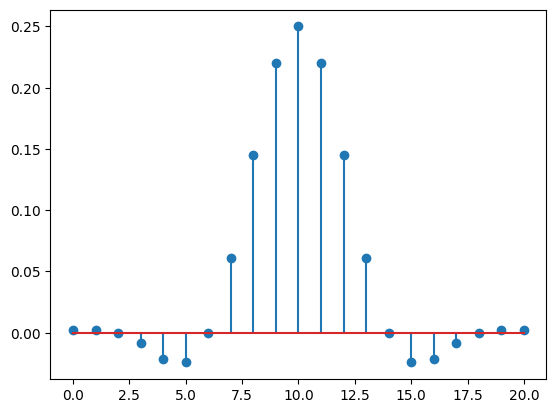

In [18]:
plt.stem(np.arange(N) , h)

In [19]:
def DFT(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-1j * 2 * np.pi * k * n / N)
    return X

In [20]:
H = DFT(h)

In [21]:
magnitude = np.abs(H)
phase = np.angle(H)

Text(0, 0.5, 'Phase (radian)')

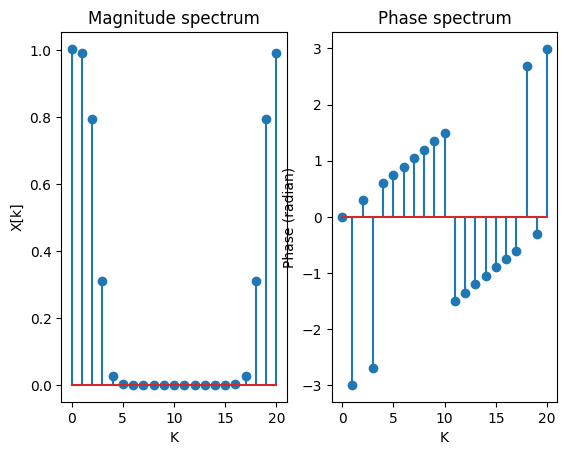

In [23]:
k = np.arange(N)

plt.Figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.stem(k, magnitude)
plt.title("Magnitude spectrum")
plt.xlabel("K")
plt.ylabel("X[k]")

plt.subplot(1, 2, 2)
plt.stem(k, phase)
plt.title("Phase spectrum")
plt.xlabel("K")
plt.ylabel("Phase (radian)")